In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
X = df[['area','bedrooms','bathrooms']]

y = df['price']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [8]:
predictions = model.predict(X_test)

print(predictions[:5])

[6383168.05981192 6230250.35140428 3597885.28090091 4289730.8386382
 3930445.60575177]


In [10]:
house = [[1500, 3, 2]]

price = model.predict(house)

print("Predicted Price:", price[0])

Predicted Price: 4502917.500988725


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


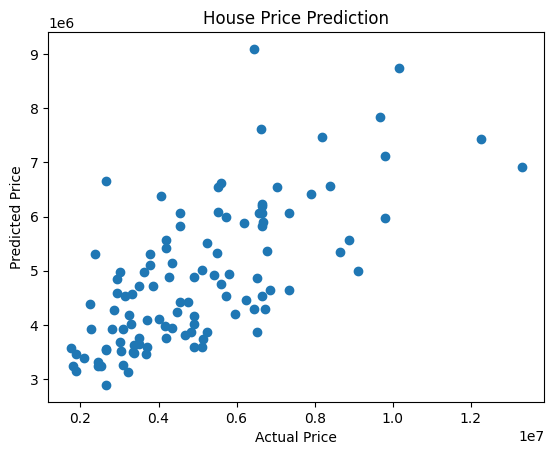

In [11]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Price Prediction")
plt.show()

In [12]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


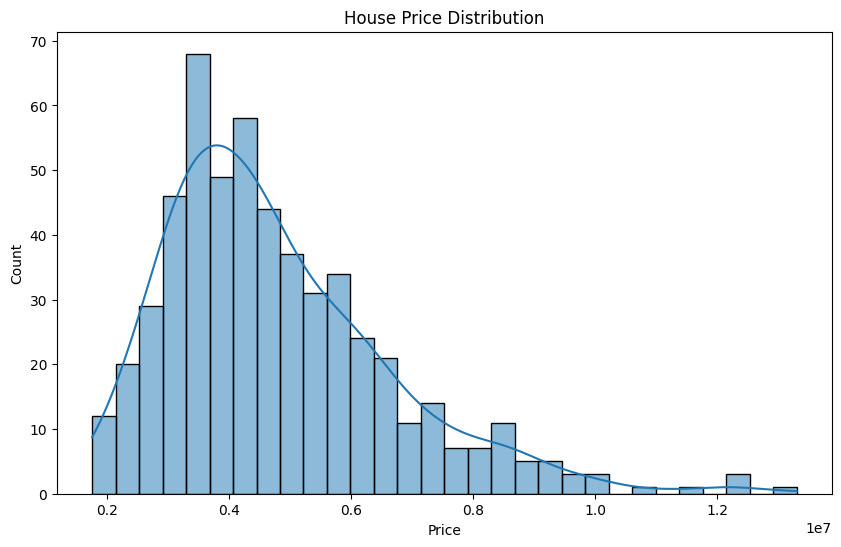

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

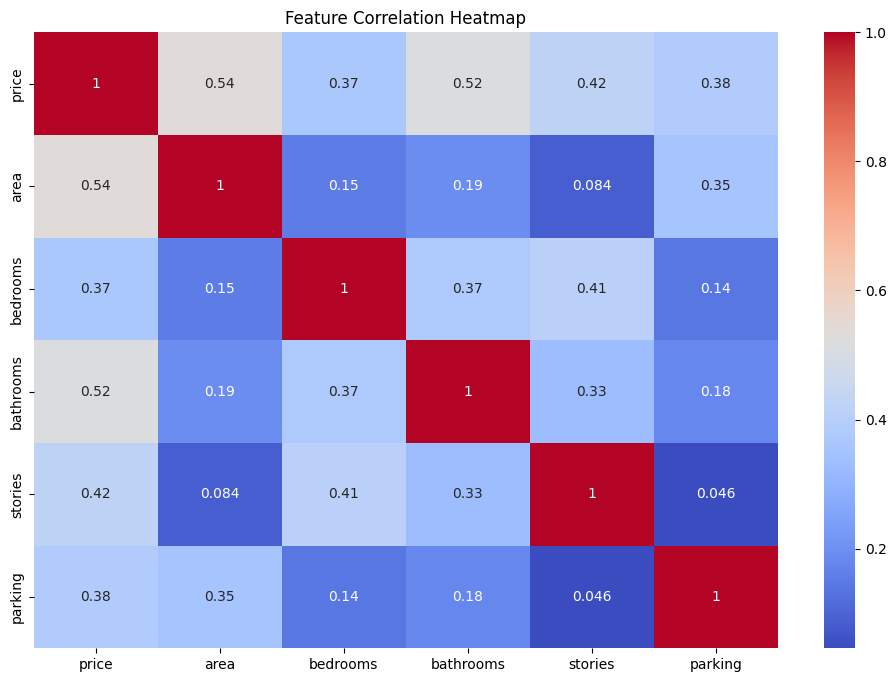

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

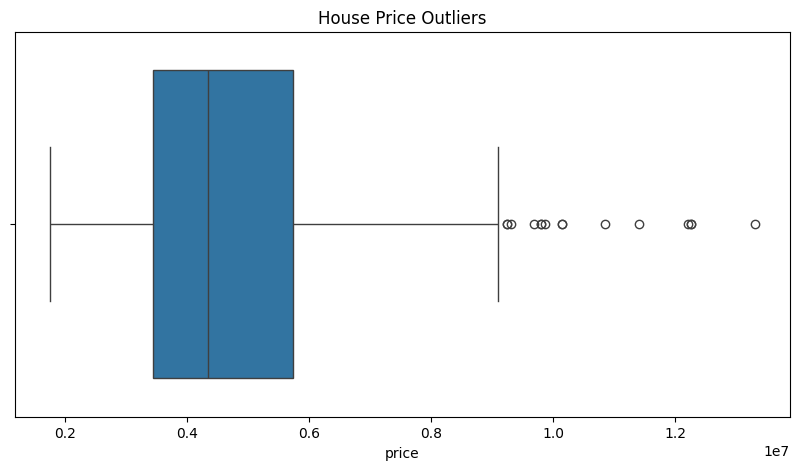

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['price'])

plt.title("House Price Outliers")

plt.show()

In [17]:
df = pd.get_dummies(df, drop_first=True)

print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [21]:
X = df.drop('price', axis=1)

y = df['price']

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = r2_score(y_test, pred)

    print(name, ":", score)

Linear Regression : 0.4559299118872445
Decision Tree : 0.20768583392286055
Random Forest : 0.4249237991737981


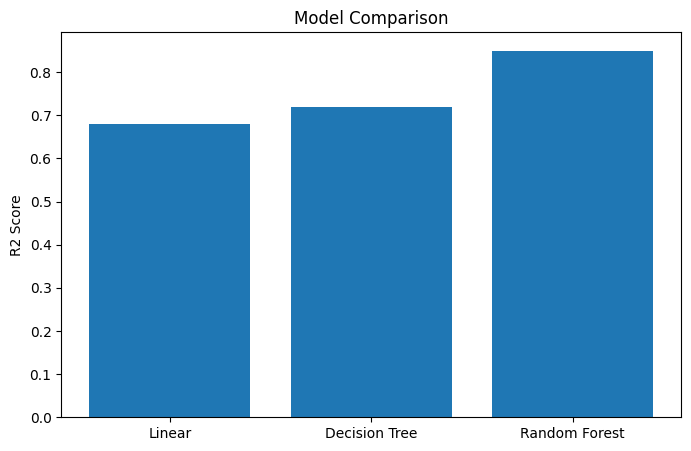

In [23]:
models = ["Linear","Decision Tree","Random Forest"]

scores = [0.68,0.72,0.85]

plt.figure(figsize=(8,5))

plt.bar(models,scores)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
df = pd.get_dummies(df, drop_first=True)

In [30]:
X = df.drop('price', axis=1)
y = df['price']

In [31]:
rf = RandomForestRegressor()

rf.fit(X_train,y_train)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                         Feature  Importance
0                           area    0.467420
2                      bathrooms    0.155723
3                        stories    0.060992
4                        parking    0.057949
9            airconditioning_yes    0.056339
1                       bedrooms    0.044455
12  furnishingstatus_unfurnished    0.036846
7                   basement_yes    0.033923
10                  prefarea_yes    0.027750
8            hotwaterheating_yes    0.019749


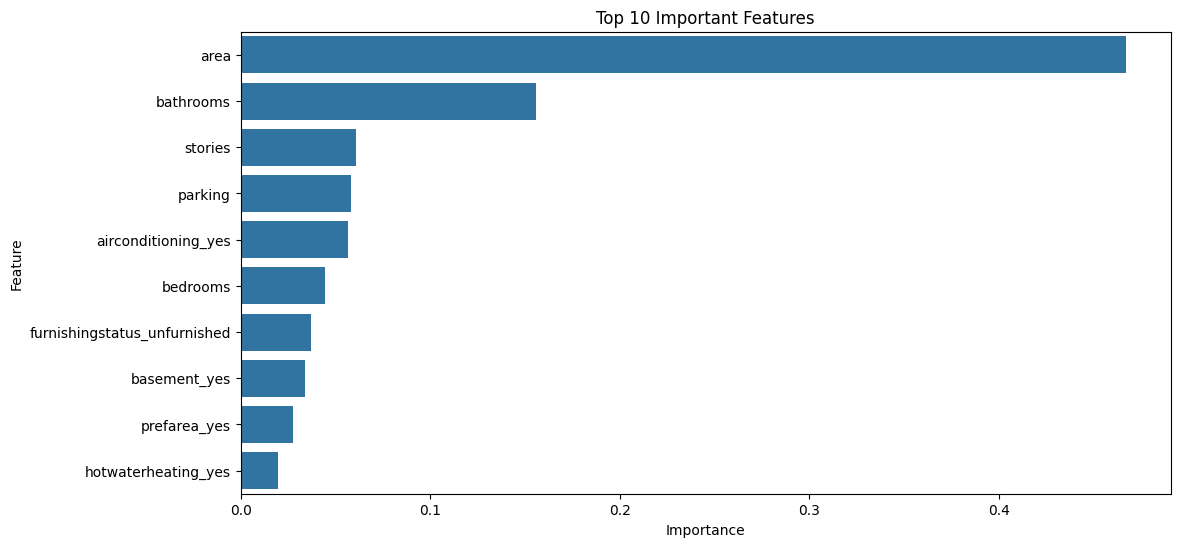

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [33]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=5
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 15, 'n_estimators': 100}


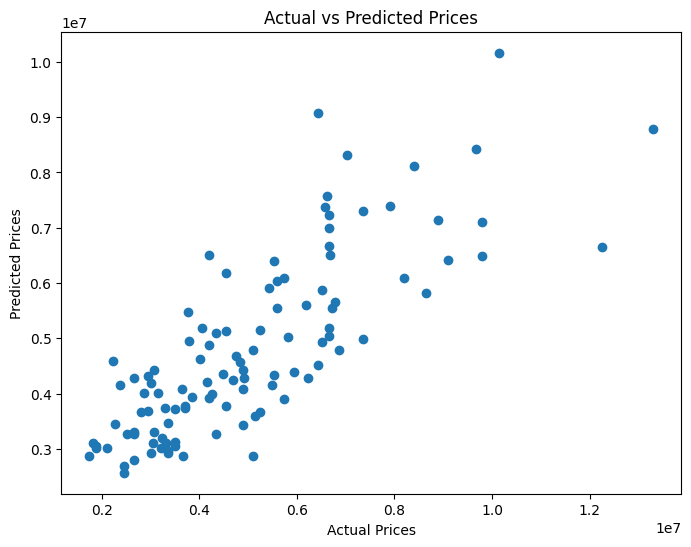

In [34]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test,pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [35]:
import pickle

pickle.dump(
    best_model,
    open("house_price_model.pkl","wb")
)

print("Model Saved")

Model Saved


In [36]:
area = 2500
bedrooms = 4
bathrooms = 3

sample = X.iloc[0:1].copy()

sample.iloc[:] = 0

sample['area'] = area
sample['bedrooms'] = bedrooms
sample['bathrooms'] = bathrooms

prediction = best_model.predict(sample)

print("Predicted Price = ₹", round(prediction[0]))

Predicted Price = ₹ 3807510


/tmp/ipykernel_1749/3245159657.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sample.iloc[:] = 0
/tmp/ipykernel_1749/3245159657.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sample.iloc[:] = 0
/tmp/ipykernel_1749/3245159657.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sample.iloc[:] = 0
/tmp/ipykernel_1749/3245159657.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please explic

DATASET LOADED SUCCESSFULLY
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

DATASET SHAPE
(545, 13)

COLUMN NAMES
Index(['price', 'area', 'bedroom

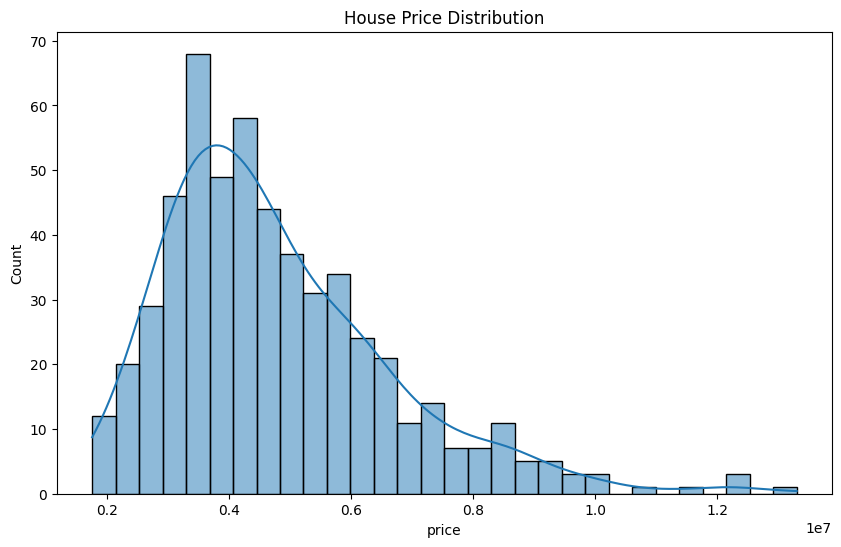

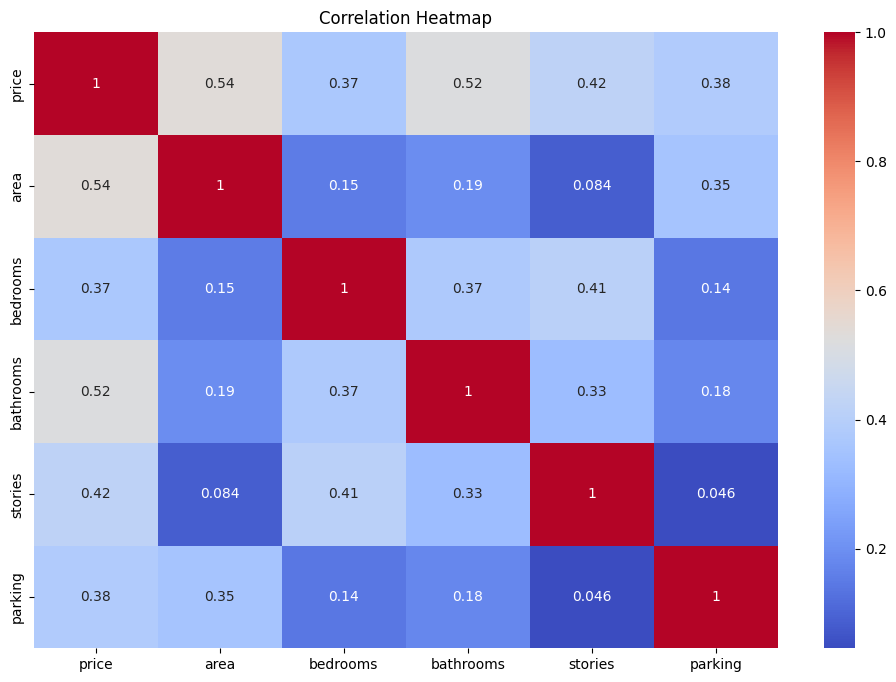

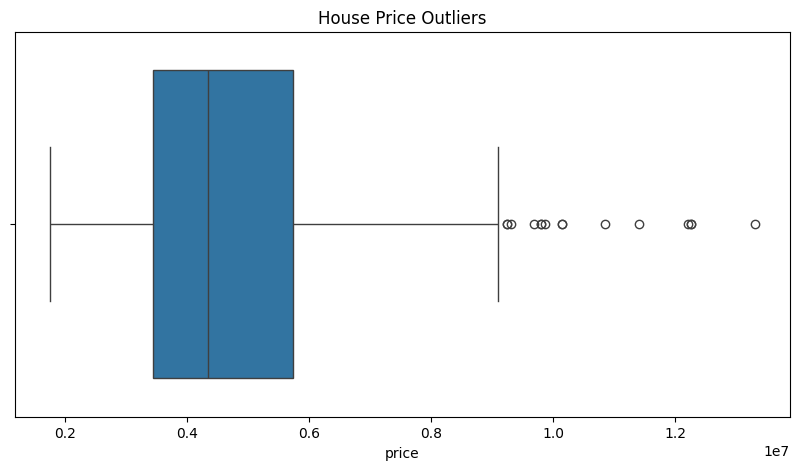

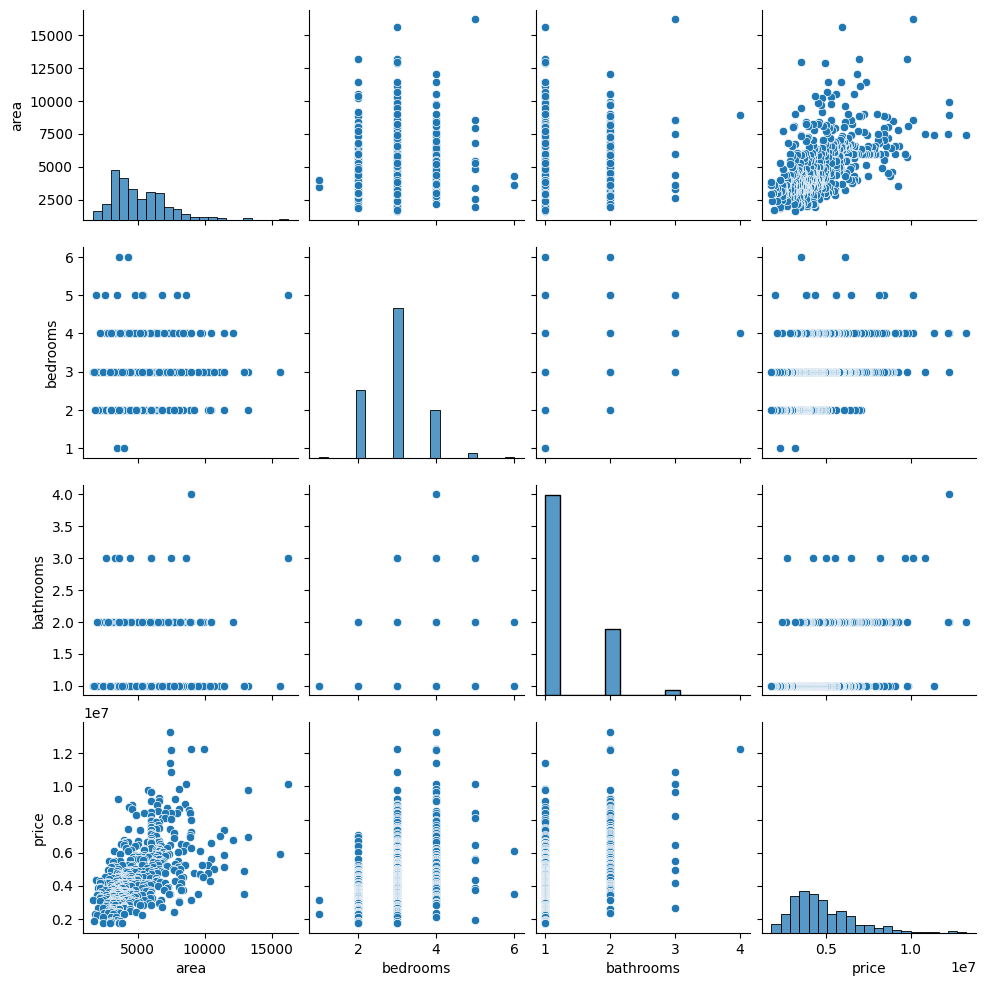


ENCODED DATASET
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  


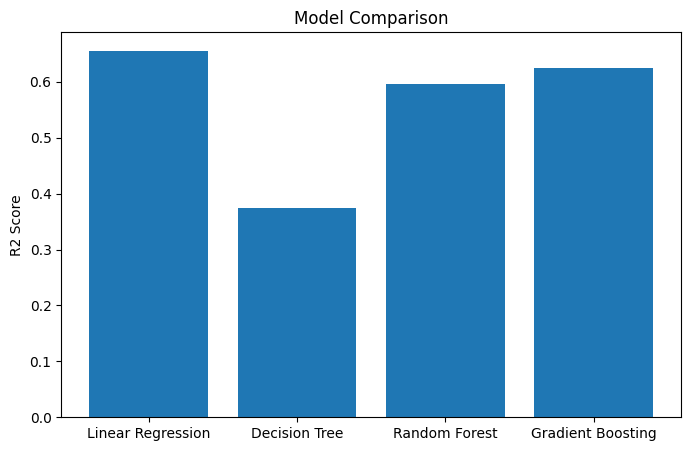

{'max_depth': 5, 'n_estimators': 200}

CROSS VALIDATION SCORES
[ -3.22226968  -7.7217099  -16.74476729 -18.52489989 -11.47962021]

AVERAGE SCORE: -11.538653394454894


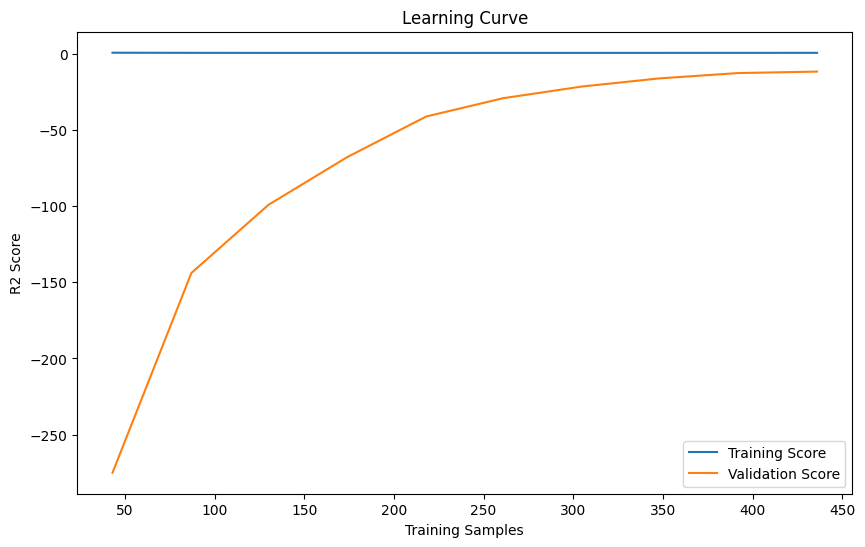


MODEL EVALUATION
MAE : 1127005.7469160839
RMSE: 1503272.5821317914
R2 : 0.5529138292584426


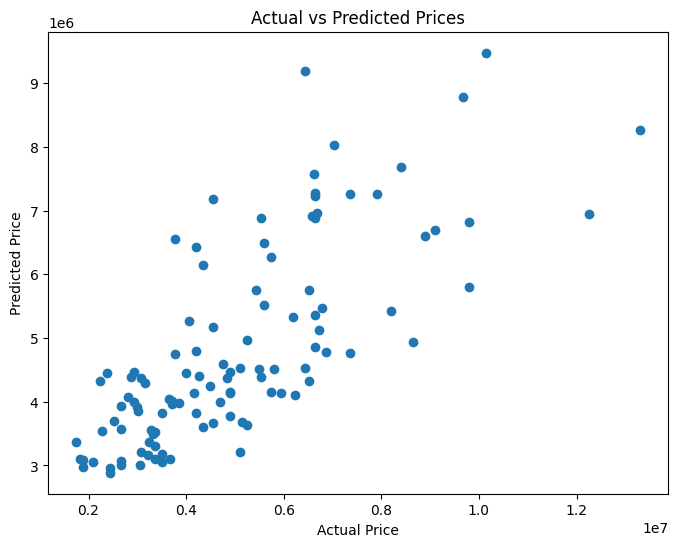

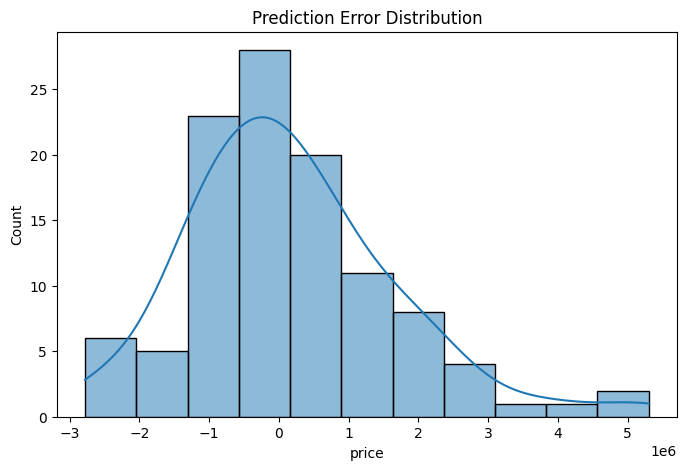

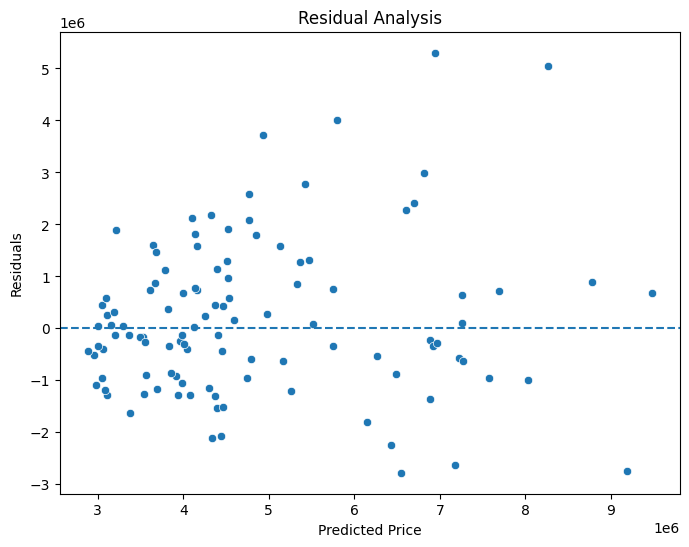


TOP FEATURES
                         Feature  Importance
0                           area    0.463223
15                   total_rooms    0.114549
2                      bathrooms    0.088810
14              bathroom_density    0.057242
9            airconditioning_yes    0.054846
3                        stories    0.039245
12  furnishingstatus_unfurnished    0.036052
4                        parking    0.034674
13                  room_density    0.026309
10                  prefarea_yes    0.024991


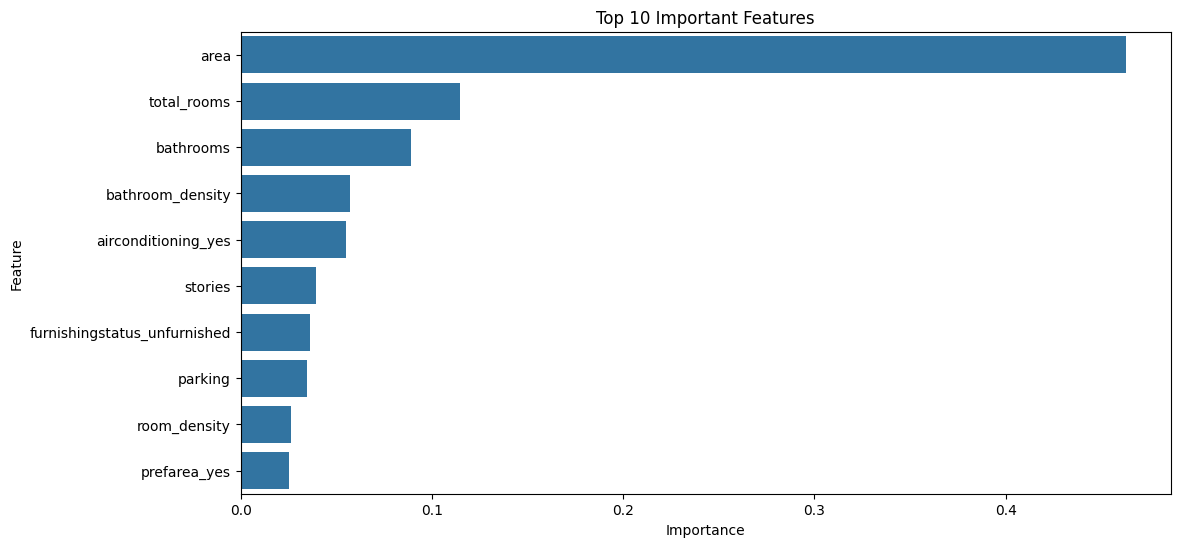


TOP 5 FACTORS AFFECTING HOUSE PRICES

                Feature  Importance
0                  area    0.463223
15          total_rooms    0.114549
2             bathrooms    0.088810
14     bathroom_density    0.057242
9   airconditioning_yes    0.054846
BEST MODEL: RandomForestRegressor
R2 SCORE: 0.5529
RMSE: 1503272.58
MAE: 1127005.75

MODEL SAVED SUCCESSFULLY

PREDICTED HOUSE PRICE
₹ 3975124

PROJECT COMPLETED SUCCESSFULLY


/tmp/ipykernel_1749/949768248.py:561: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sample.iloc[:] = 0
/tmp/ipykernel_1749/949768248.py:561: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sample.iloc[:] = 0
/tmp/ipykernel_1749/949768248.py:561: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sample.iloc[:] = 0
/tmp/ipykernel_1749/949768248.py:561: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0' has dtype incompatible with bool, please ex

In [46]:
# ==========================================================
# HOUSE PRICE PREDICTION USING MACHINE LEARNING
# ==========================================================

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # Added GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# ==========================================================
# 2. LOAD DATASET
# ==========================================================

df = pd.read_csv("Housing.csv")

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

print(df.head())


# ==========================================================
# 3. DATASET INFORMATION
# ==========================================================

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDATASET INFO")
print(df.info())


# ==========================================================
# 4. STATISTICAL SUMMARY
# ==========================================================

print("\nSTATISTICAL SUMMARY")
print(df.describe())


# ==========================================================
# 5. DATA CLEANING
# ==========================================================

df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMISSING VALUES HANDLED")


# ==========================================================
# 6. HOUSE PRICE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['price'],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")
plt.show()


# ==========================================================
# 7. CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


# ==========================================================
# 8. OUTLIER DETECTION
# ==========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["price"]
)

plt.title("House Price Outliers")
plt.show()


# ==========================================================
# 9. PAIR PLOT
# ==========================================================

sns.pairplot(
    df[
        [
            "area",
            "bedrooms",
            "bathrooms",
            "price"
        ]
    ]
)

plt.show()


# ==========================================================
# 10. ENCODE CATEGORICAL VARIABLES
# ==========================================================

df = pd.get_dummies(
    df,
    drop_first=True
)

print("\nENCODED DATASET")
print(df.head())

# ==========================================================
# 11. ADVANCED FEATURE ENGINEERING
# ==========================================================

df["room_density"] = (
    df["bedrooms"] /
    df["area"]
)

df["bathroom_density"] = (
    df["bathrooms"] /
    df["area"]
)

df["total_rooms"] = (
    df["bedrooms"] +
    df["bathrooms"]
)

print("\nADVANCED FEATURE ENGINEERING COMPLETED")




# ==========================================================
# 12. FEATURE SELECTION
# ==========================================================

X = df.drop(
    "price",
    axis=1
)

y = df["price"]
print(df.shape)

print(X.shape)

print(y.shape)
print(df.columns)
# ==========================================================
# 13. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTRAIN TEST SPLIT COMPLETED")


# ==========================================================
# 14. MULTIPLE MODEL TRAINING
# ==========================================================
models = {

    "Linear Regression":
    LinearRegression(),

    "Decision Tree":
    DecisionTreeRegressor(),

    "Random Forest":
    RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingRegressor(
        random_state=42
    )
}

results = {} # Initialize dictionary to store results

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = r2_score(y_test, pred)
    results[name] = score # Store the score
    print(f"{name}: {score:.4f}") # Print the score for each model

# ==========================================================
# 15. MODEL COMPARISON GRAPH
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    results.keys(),
    results.values()
)

plt.title("Model Comparison")
plt.ylabel("R2 Score")

plt.show()


# ==========================================================
# 16. HYPERPARAMETER TUNING
# ==========================================================
params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
# ==========================================================
# 17. BEST MODEL
# ==========================================================

best_model = grid.best_estimator_


# ==========================================================
# 18. CROSS VALIDATION
# ==========================================================

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCROSS VALIDATION SCORES")
print(scores)

print(
    "\nAVERAGE SCORE:",
    scores.mean()
)
# ==========================================================
# LEARNING CURVE
# ==========================================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(

    best_model,

    X,

    y,

    cv=5,

    scoring="r2",

    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    )
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    test_mean,
    label="Validation Score"
)

plt.xlabel("Training Samples")
plt.ylabel("R2 Score")

plt.title("Learning Curve")

plt.legend()

plt.show()

# ==========================================================
# 19. MODEL EVALUATION
# ==========================================================

predictions = best_model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nMODEL EVALUATION")

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)


# ==========================================================
# 20. ACTUAL VS PREDICTED GRAPH
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()


# ==========================================================
# 21. ERROR DISTRIBUTION
# ==========================================================

errors = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(
    errors,
    kde=True
)

plt.title("Prediction Error Distribution")

plt.show()
# ==========================================================
# 21A. RESIDUAL ANALYSIS
# ==========================================================

residuals = (
    y_test -
    predictions
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Residual Analysis"
)

plt.xlabel(
    "Predicted Price"
)

plt.ylabel(
    "Residuals"
)

plt.show()

# ==========================================================
# 22. FEATURE IMPORTANCE
# ==========================================================

importance = best_model.feature_importances_

feature_importance = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTOP FEATURES")
print(
    feature_importance.head(10)
)


# ==========================================================
# 23. FEATURE IMPORTANCE GRAPH
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()
# ==========================================================
# 23A. BUSINESS INSIGHTS
# ==========================================================

print(
    "\nTOP 5 FACTORS AFFECTING HOUSE PRICES\n"
)

print(
    feature_importance.head(5)
)
# ==========================================================
# FINAL MODEL SUMMARY
# ==========================================================

print("="*60)

print(
    "BEST MODEL:",
    type(best_model).__name__
)

print(
    "R2 SCORE:",
    round(r2,4)
)

print(
    "RMSE:",
    round(rmse,2)
)

print(
    "MAE:",
    round(mae,2)
)

print("="*60)
# ==========================================================
# 24. SAVE MODEL
# ==========================================================

pickle.dump(
    best_model,
    open(
        "house_price_model.pkl",
        "wb"
    )
)

print("\nMODEL SAVED SUCCESSFULLY")


# ==========================================================
# 25. LOAD MODEL
# ==========================================================

model = pickle.load(
    open(
        "house_price_model.pkl",
        "rb"
    )
)


# ==========================================================
# 26. CUSTOM HOUSE PRICE PREDICTION
# ==========================================================

sample = X.iloc[0:1].copy()

sample.iloc[:] = 0

sample["area"] = 2500
sample["bedrooms"] = 4
sample["bathrooms"] = 3

prediction = model.predict(
    sample
)

print("\nPREDICTED HOUSE PRICE")

print(
    "₹",
    round(prediction[0])
)

print("\nPROJECT COMPLETED SUCCESSFULLY")

In [47]:
import pickle

pickle.dump(
    best_model,
    open("house_price_model.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [48]:
import os

print(os.listdir())

['.config', 'house_price_model.pkl', 'Housing.csv', 'sample_data']


In [49]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>